In [1]:
from pystac_client import Client
from collections import Counter

pc = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
for c in pc.get_collections():
    if "sentinel-1" in c.id or "rtc" in c.id.lower():
        print(c.id, "—", c.title)


sentinel-1-rtc — Sentinel 1 Radiometrically Terrain Corrected (RTC)
sentinel-1-grd — Sentinel 1 Level-1 Ground Range Detected (GRD)


In [2]:
search = pc.search(
    collections=["sentinel-1-rtc"],
    bbox=[10.3635, 51.6196, 10.7794, 51.8868],
    datetime="2022-02-01/2022-03-01",
)
items = list(search.items())
print(len(items))
if items:
    p = items[0].properties
    print({k: p[k] for k in p if "orbit" in k or "polar" in k or "pass" in k})
    print(list(items[0].assets))

11
{'s1:orbit_source': 'RESORB', 'sat:orbit_state': 'descending', 'sar:polarizations': ['VV', 'VH'], 'sat:absolute_orbit': 42065, 'sat:relative_orbit': 168}
['vh', 'vv', 'tilejson', 'rendered_preview']


In [3]:
rows = [(it.properties["sat:relative_orbit"],
         it.properties["sat:orbit_state"],
         it.properties["datetime"][:10]) for it in items]

for orbit, state in sorted(set((r[0], r[1]) for r in rows)):
    dates = sorted(d for o, s, d in rows if o == orbit)
    print(orbit, state, len(dates), dates)


import planetary_computer as pc_sign
import rioxarray as rxr

o168 = sorted([i for i in items
               if i.properties["sat:relative_orbit"] == 168],
              key=lambda i: i.properties["datetime"])

44 ascending 2 ['2022-02-04', '2022-02-16']
66 descending 2 ['2022-02-06', '2022-02-18']
117 ascending 4 ['2022-02-09', '2022-02-09', '2022-02-21', '2022-02-21']
168 descending 3 ['2022-02-01', '2022-02-13', '2022-02-25']


In [6]:
from pathlib import Path
ROOT = Path.cwd().parent

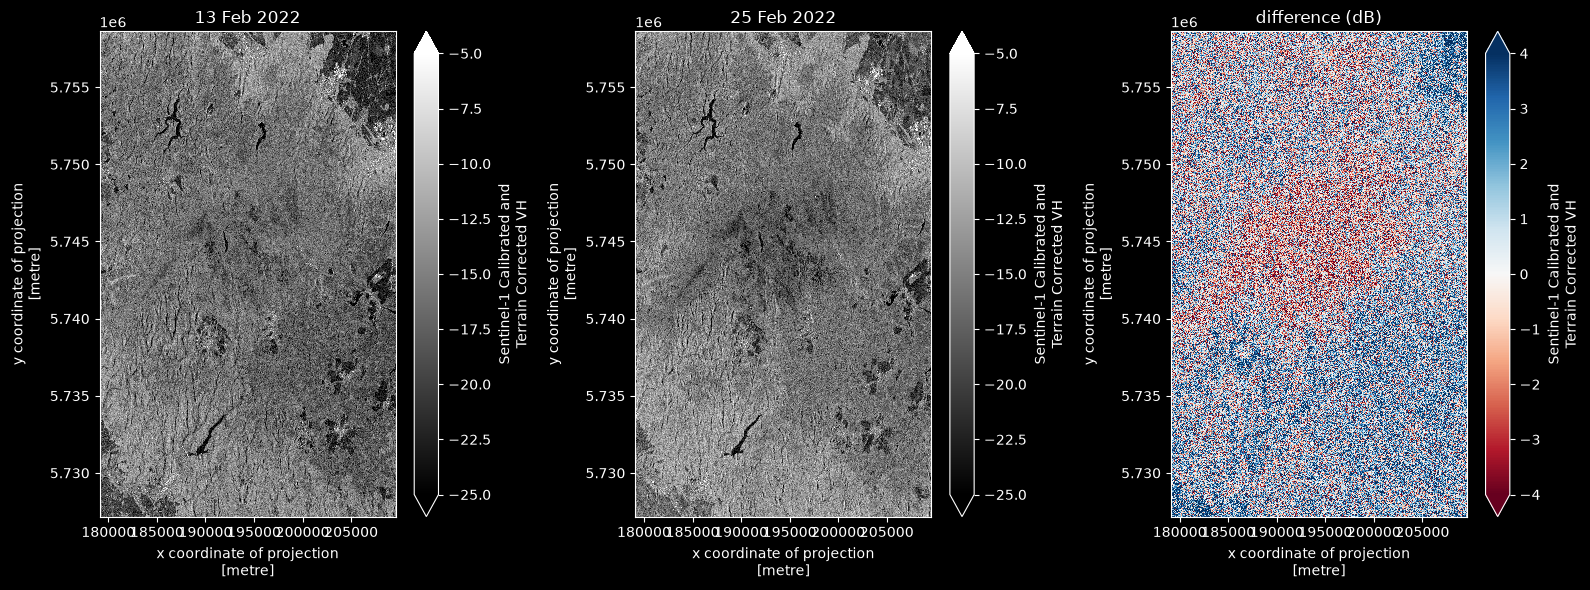

In [7]:
import numpy as np, matplotlib.pyplot as plt, geopandas as gpd

aoi = gpd.read_file(ROOT / "data/raw/aoi.gpkg").to_crs(32633)
minx, miny, maxx, maxy = aoi.total_bounds

def load(item, band="vh"):
    da = rxr.open_rasterio(pc_sign.sign(item).assets[band].href,
                           chunks={"x": 1024, "y": 1024})
    da = da.rio.clip_box(minx, miny, maxx, maxy)
    return (10 * np.log10(da)).squeeze().compute()

before = load(o168[1])   # 2022-02-13
after  = load(o168[2])   # 2022-02-25
diff   = after - before

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
before.plot(ax=axes[0], vmin=-25, vmax=-5, cmap="gray")
after.plot(ax=axes[1], vmin=-25, vmax=-5, cmap="gray")
diff.plot(ax=axes[2], vmin=-4, vmax=4, cmap="RdBu")
for a, t in zip(axes, ["13 Feb 2022", "25 Feb 2022", "difference (dB)"]):
    a.set_title(t)
plt.tight_layout()